# Image Compression with K-means Clustering

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from random import sample
import scipy.misc
import matplotlib.cm as cm
from scipy import linalg
import imageio

/tmp/ipykernel_31887/2042263740.py:6: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1: Implementing K-means

### 1.1: Finding closest centroids

In [3]:
try:
  datafile = '/content/drive/MyDrive/HamrahAcademy/ML-Unsupervised/project/HW1/data.mat' # call the MATLAB file path
except:
  datafile = 'data.mat'
finally:
  mat = scipy.io.loadmat( datafile )
  X = mat['X']

In [4]:
#Choose the number of centroids... K = 3
K = 3
initial_centroids = np.array([[3,3],[6,2],[8,5]]) # example initial value of centroids

In [5]:
# Visualizing the data, please don't change the code below!
def plotData(myX,mycentroids,myidxs = None):
    """
    Fucntion to plot the data and color it accordingly.
    myidxs should be the latest iteraction index vector
    mycentroids should be a vector of centroids, one per iteration
    """

    colors = ['b','g','gold','darkorange','salmon','olivedrab']

    assert myX[0].shape == mycentroids[0][0].shape
    assert mycentroids[-1].shape[0] <= len(colors)

    #If idxs is supplied, divide up X into colors
    if myidxs is not None:
        assert myidxs.shape[0] == myX.shape[0]
        subX = []
        for x in range(mycentroids[0].shape[0]):
            subX.append(np.array([myX[i] for i in range(myX.shape[0]) if myidxs[i] == x]))
    else:
        subX = [myX]

    fig = plt.figure(figsize=(7,5))
    for x in range(len(subX)):
        newX = subX[x]
        plt.plot(newX[:,0],newX[:,1],'o',color=colors[x],
                 alpha=0.75, label='Data Points: Cluster %d'%x)
    plt.xlabel('x1',fontsize=14)
    plt.ylabel('x2',fontsize=14)
    plt.title('Plot of X Points',fontsize=16)
    plt.grid(True)

    #Drawing a history of centroid movement
    tempx, tempy = [], []
    for mycentroid in mycentroids:
        tempx.append(mycentroid[:,0])
        tempy.append(mycentroid[:,1])

    for x in range(len(tempx[0])):
        plt.plot(tempx, tempy, 'rx--', markersize=8)

    leg = plt.legend(loc=4, framealpha=0.5)

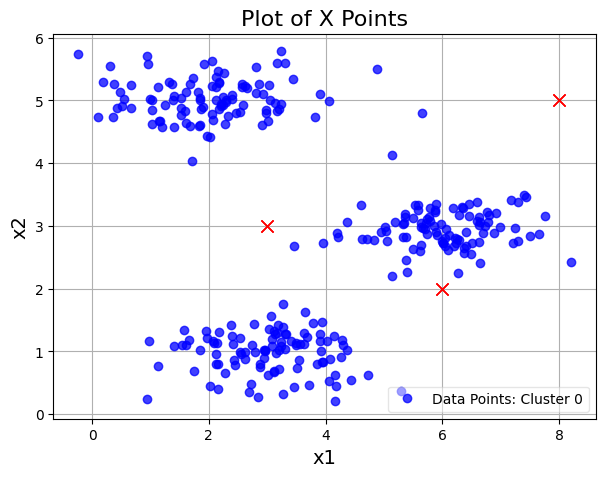

In [6]:
plotData(X,[initial_centroids])

In [7]:
def distSquared(point1, point2):
    # this function should return the squared distance between two points
    distance = np.sum((point1 - point2)**2)
    return distance

In [8]:
X.shape

(300, 2)

In [9]:
def findClosestCentroids(myX, mycentroids):
    """
    Function takes in the (m,n) X matrix
    (where m is the # of points, n is # of features per point)
    and the (K,n) centroid seed matrix
    (where K is the # of centroids (clusters)
    and returns a (m,1) vector of cluster indices
    per point in X (0 through K-1)
    """
    idxs = np.zeros((myX.shape[0],1))

    #Loop through each data point in X
    for x in range(idxs.shape[0]):
        # Write code here

        point = myX[x]

        #Then compare this point to each centroid,
        #Keep track of shortest distance and index of shortest distance
        mindist, idx = 9999999, 0
        for i in range(mycentroids.shape[0]):
            # Write code here
            distance = distSquared(point,mycentroids[i])
            if distance < mindist:
                mindist = distance
                idx = i

        #With the best index found, modify the result idx vector
        # Write code here
        idxs[x] = idx

    return idxs

In [10]:
idxs = findClosestCentroids(X,initial_centroids)

#you should see the output [1 3 2] corresponding to the centroid assignments for the first 3 examples.

# print indices here (Hint: output should be [0 2 1])
print(idxs[:3])

[[0.]
 [2.]
 [1.]]


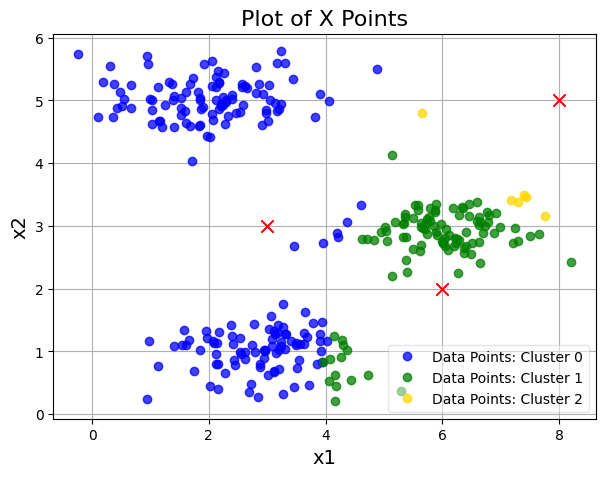

In [11]:
plotData(X,[initial_centroids],idxs)

### 1.2: Computing centroid means

In [12]:
def computeCentroids(myX, myidxs):
    """
    Function takes in the X matrix and the index vector
    and computes a new centroid matrix.
    """

    # Write code here
    K = len(np.unique(myidxs))
    n = myX.shape[1]
    new_centroids = np.zeros((K, n))

    for i in range(K):
        # Select all data points that belong to cluster i
        points_in_cluster = myX[myidxs.flatten() == i]
        if len(points_in_cluster) > 0:
            new_centroids[i] = np.mean(points_in_cluster, axis=0)

    return new_centroids

## 2: K-means on example dataset

In [13]:
np.unique(idxs)


array([0., 1., 2.])

In [14]:
def runKMeans(myX, initial_centroids, K, n_iter):
    centroid_history = []
    current_centroids = initial_centroids
    for myiter in range(n_iter):
        centroid_history.append(current_centroids)
        idxs = findClosestCentroids(myX, current_centroids)  # use the functions above to calculate the closest centroid
        current_centroids = computeCentroids(myX, idxs)# use the function above to compute new centroids

    return idxs, centroid_history

In [15]:
idxs, centroid_history = runKMeans(
                        myX=X,
                        initial_centroids=initial_centroids,
                        K = 3,
                        n_iter = 10) # use the function above to run kmeans method

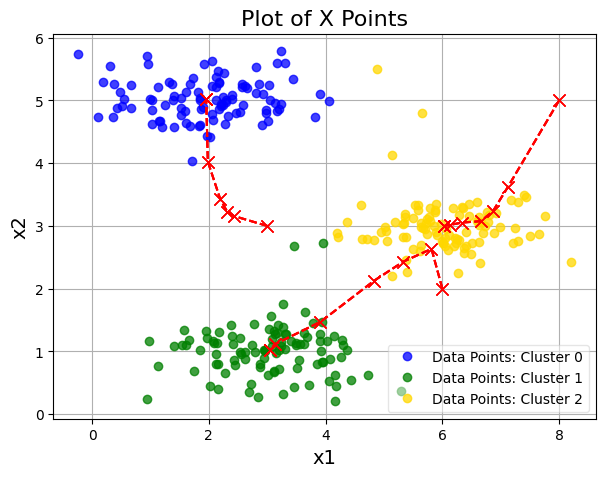

In [16]:
plotData(X,centroid_history,idxs)

## 3: Random initialization

In [17]:
def chooseKRandomCentroids(myX, K):
    rand_indices = sample(range(0,myX.shape[0]),K)
    return np.array([myX[i] for i in rand_indices])

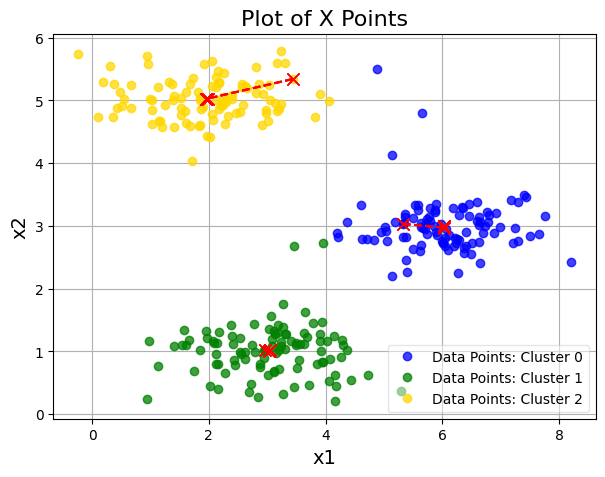

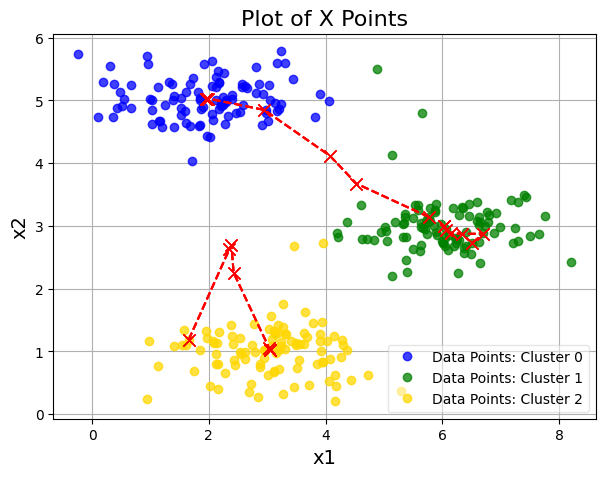

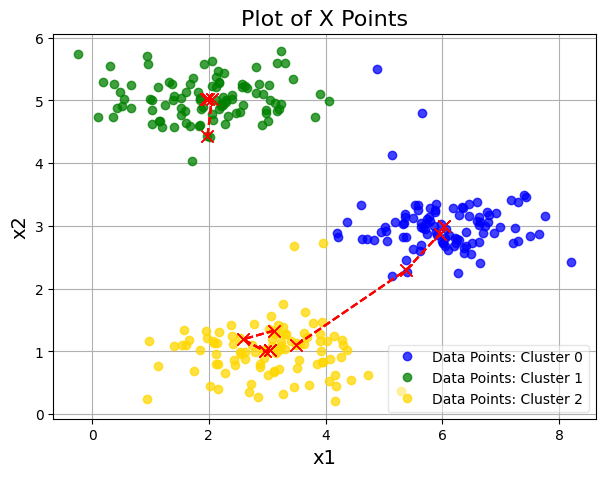

In [18]:
#Let's choose random initial centroids and see the resulting
for x in range(3):
    idxs, centroid_history = runKMeans(
                              myX=X,
                              initial_centroids=chooseKRandomCentroids(X, 3),
                              K = 3,
                              n_iter = 10) # Write code here
    plotData(X, centroid_history,idxs)

## 4: Image compression with K-means

### 4.1: K-means on pixels

/tmp/ipykernel_31887/3166816367.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  A = imageio.imread(datafile)


A shape is  (699, 700, 3)


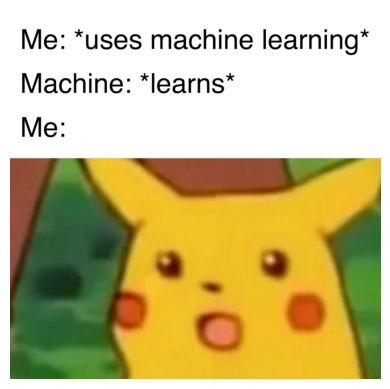

In [19]:


# This creates a three-dimensional matrix A whose first two indices
# identify a pixel position and whose last index represents red, green, or blue.
# read the image with imageio

try:
  datafile = '/content/drive/MyDrive/HamrahAcademy/ML-Unsupervised/project/HW1/sample1.png'
except:
  datafile = 'sample1.png'
finally:
  A = imageio.imread(datafile)

print("A shape is ", A.shape)
plt.axis("off")
dummy = plt.imshow(A)

In [ ]:
# Divide every entry in A by 255 so all values are in the range of 0 to 1
A = A / 255.

# Unroll the image to shape (16384,3) (16384 is 128*128)
A = A.reshape(-1, 3) # Write code here

# Run k-means on this data, forming 16 clusters, with random initialization
myK = 16
# use functions above to complete this line of the code
idxs, centroid_history = runKMeans(
                        myX=A,
                        initial_centroids=chooseKRandomCentroids(A, myK),
                        K = myK,
                        n_iter = 10)

In [ ]:
# Now I have 16 centroids, each representing a color.
# Let's assign an index to each pixel in the original image dictating
# which of the 16 colors it should be
idxs = findClosestCentroids(A, centroid_history[-1]) # find the closest centroid here

In [ ]:
final_centroids = centroid_history[-1]
# Now loop through the original image and form a new image
# that only has 16 colors in it
final_image = np.zeros((idxs.shape[0],3))
for x in range(final_image.shape[0]):
    final_image[x] = final_centroids[int(idxs[x])]

/tmp/ipykernel_31887/3320977391.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  final_image[x] = final_centroids[int(idxs[x])]


In [ ]:
# Reshape the original image and the new, final image and draw them
plt.figure()
plt.axis("off")
dummy = plt.imshow(A.reshape(699, -1, 3)) # complete this line with reshaping
plt.figure()
plt.axis("off")
dummy = plt.imshow(final_image.reshape(699, -1, 3)) # complete this line with reshaping